# Viewing the 

(head, info, hist)

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_dataset_path = Path("../datasets/housing.csv")
dataframe = pd.read_csv(csv_dataset_path)

dataframe.info()
dataframe.head()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


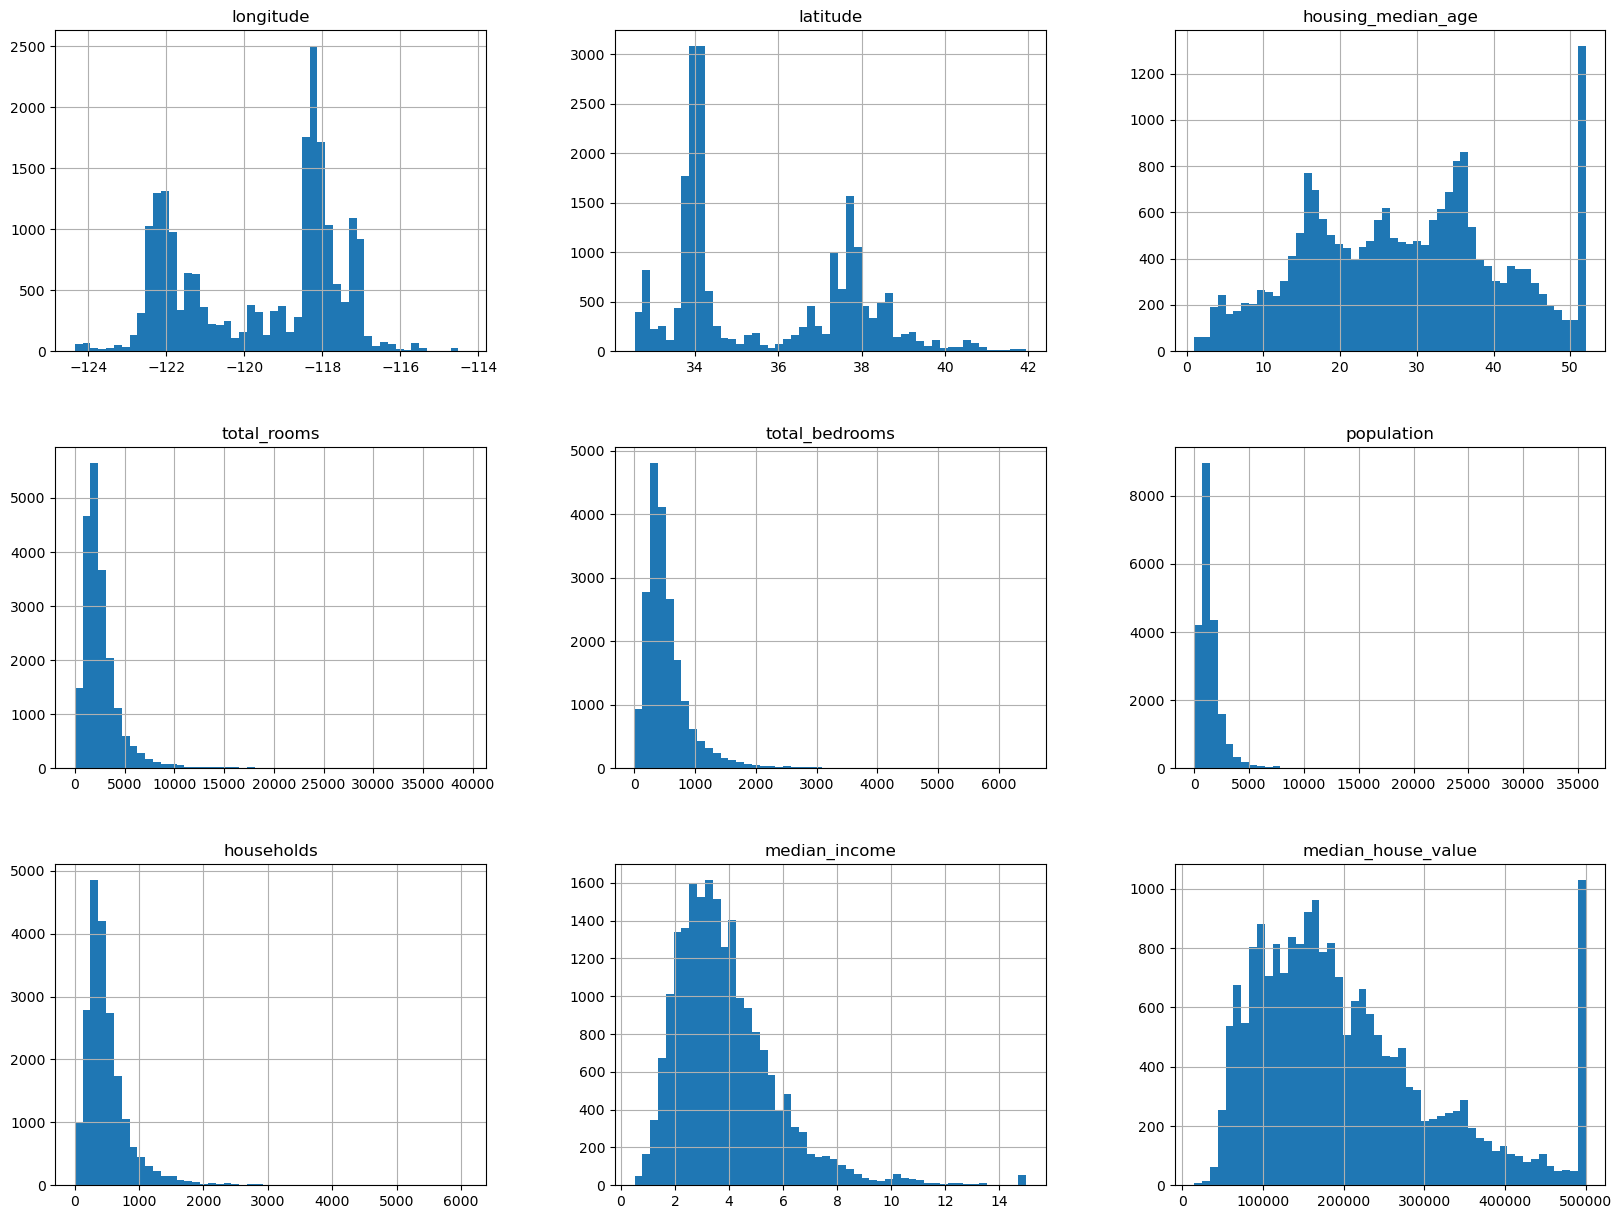

In [4]:
dataframe.hist(bins=50, figsize=(20, 15))
plt.show()

In [5]:
dataframe.describe().loc[['min','max','mean','std']]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874


# GET THE DATA
Create a testset that change with each run
(test, train set)

In [6]:
TEST_RATIO = 0.2

shuffle_indexes = np.random.permutation(len(dataframe))
test_set_size = int(len(dataframe) * TEST_RATIO)
test_indexes = shuffle_indexes[:test_set_size]
train_indexes = shuffle_indexes[test_set_size:]

test_set = dataframe.iloc[test_indexes]
train_set = dataframe.iloc[train_indexes]

test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
10259,-120.74,39.90,23.0,1017.0,218.0,387.0,152.0,2.2656,88200.0,INLAND
267,-121.93,36.63,28.0,3983.0,852.0,1582.0,778.0,3.5147,313900.0,NEAR OCEAN
304,-116.50,33.81,26.0,5032.0,1229.0,3086.0,1183.0,2.5399,94800.0,INLAND
5355,-120.41,34.88,4.0,3680.0,559.0,1678.0,569.0,5.0639,201700.0,<1H OCEAN
16946,-120.42,34.95,33.0,3404.0,711.0,1579.0,639.0,3.1078,146700.0,<1H OCEAN


Create a testset that does **not** change with each run

In [7]:
from zlib import crc32

def is_id_in_test_set(id):
    return crc32(np.int64(id)) < TEST_RATIO * 2**32

def split_data_with_id_hash(dataframe, id_column):
    ids = dataframe[id_column]
    in_test_set_array = ids.apply(lambda id_: is_id_in_test_set(id_))
    return dataframe.loc[~in_test_set_array], dataframe.loc[in_test_set_array]

dataframe_with_id = dataframe.reset_index()
train_set, test_set = split_data_with_id_hash(dataframe_with_id, "index")

test_set.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2,2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
5,5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
12,12,-122.26,37.85,52.0,2491.0,474.0,1098.0,468.0,3.0750,213500.0,NEAR BAY
16,16,-122.27,37.85,52.0,1966.0,347.0,793.0,331.0,2.7750,152500.0,NEAR BAY
23,23,-122.27,37.84,52.0,1688.0,337.0,853.0,325.0,2.1806,99700.0,NEAR BAY


I divide the median_income in the dataframe into 5 categories

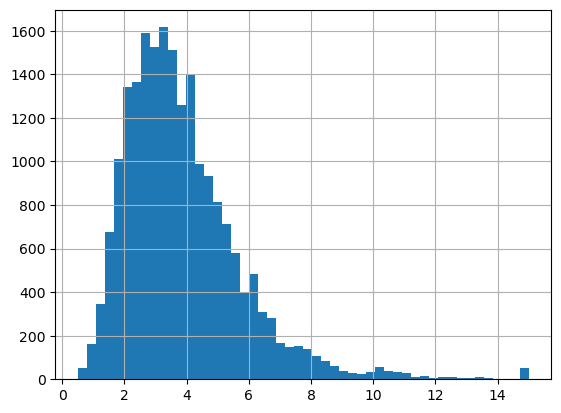

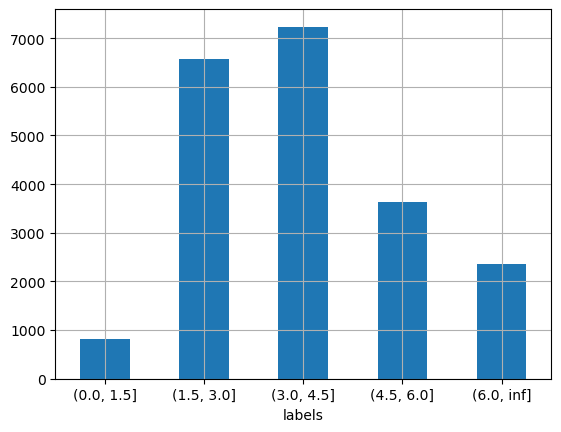

In [8]:
dataframe["median_income"].hist(bins=50)
plt.show()

dataframe["income_cat"] = pd.cut(dataframe["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               ) #labels=[1, 2, 3, 4, 5]


dataframe["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("labels")
plt.show()

Create multiple stratified splits of the housing dataset using the income_cat column as the stratification category

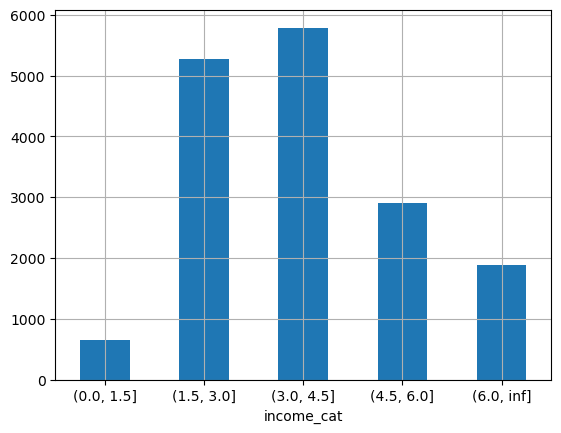

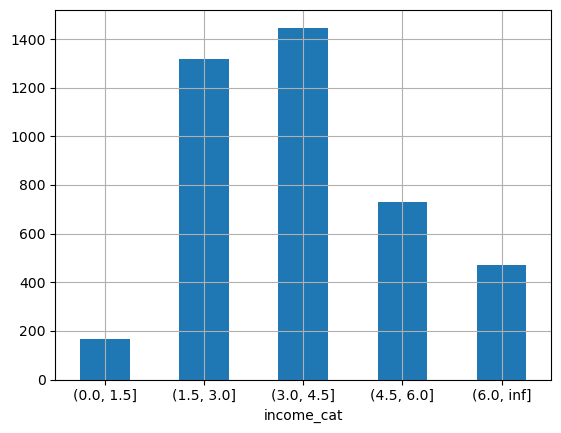

income_cat
(3.0, 4.5]    0.350533
(1.5, 3.0]    0.318798
(4.5, 6.0]    0.176357
(6.0, inf]    0.114341
(0.0, 1.5]    0.039971
Name: count, dtype: float64

In [9]:
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split

# Multiple splits (cross-validation)
splitter = StratifiedShuffleSplit(n_splits=10, test_size=TEST_RATIO, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(dataframe, dataframe["income_cat"]):
    strat_train_set_n = dataframe.iloc[train_index]
    strat_test_set_n = dataframe.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

strat_train_set, strat_test_set = strat_splits[0]

strat_train_set["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.show()
strat_test_set["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.show()

# Alternative way to do the same thing with train_test_split, just one split
strat_train_set, strat_test_set = train_test_split(dataframe, test_size=TEST_RATIO, random_state=42, stratify=dataframe["income_cat"])

strat_test_set["income_cat"].value_counts() / len(strat_test_set)

Remove the income_cat column from the test and training sets

In [10]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# DATA VISUALIZATION
(scatter plot)

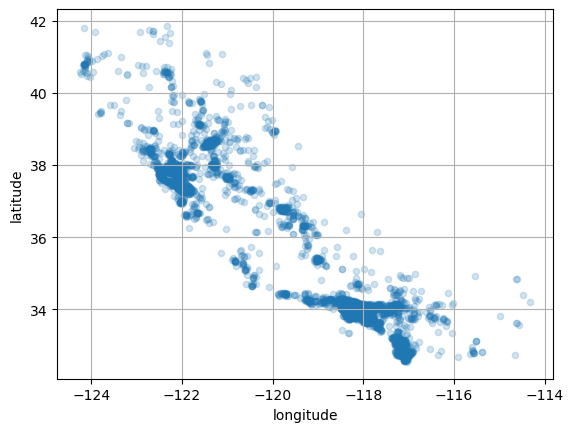

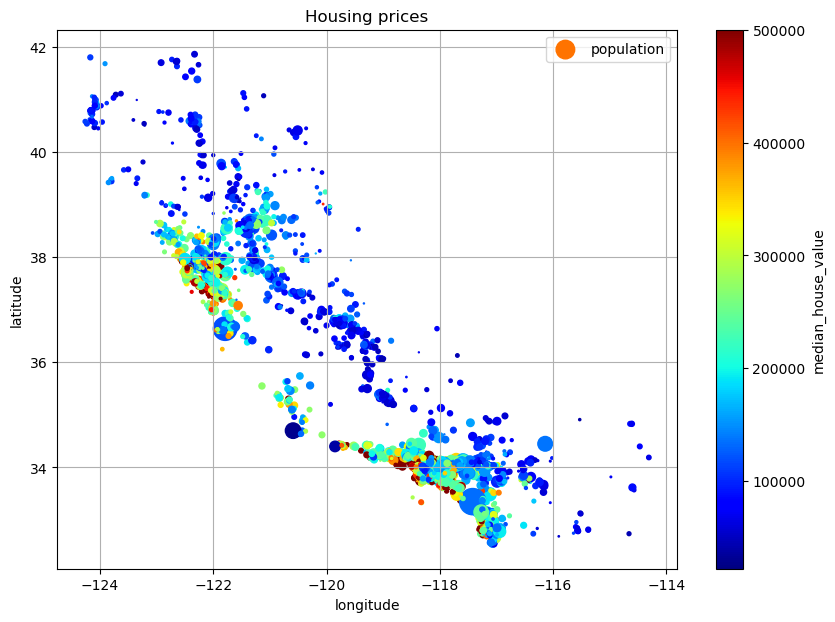

In [11]:
test_set_copy = strat_test_set.copy()

test_set_copy.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

test_set_copy.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=test_set_copy["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
plt.title("Housing prices")
plt.show()


Look for correlation

In [12]:
correlation_matrix = test_set_copy.corr(numeric_only=True)
correlation_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687091
total_rooms           0.121070
housing_median_age    0.118976
households            0.043549
total_bedrooms        0.029600
longitude            -0.026768
population           -0.040286
latitude             -0.162087
Name: median_house_value, dtype: float64

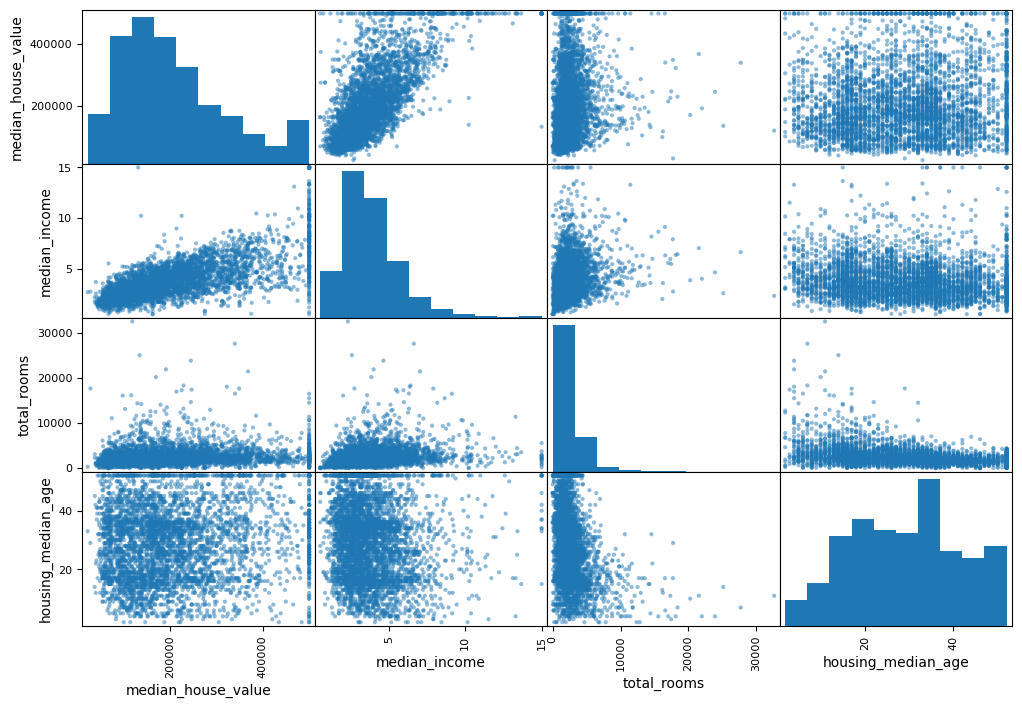

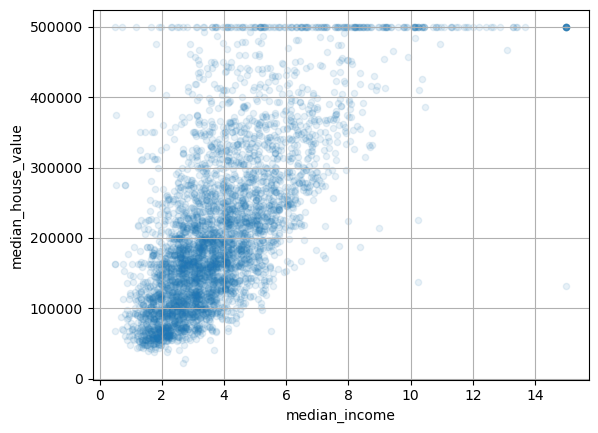

In [13]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(test_set_copy[attributes], figsize=(12, 8))
plt.show()

test_set_copy.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
plt.show()

Experimenting with Attribute Combinations

In [14]:
test_set_copy["rooms_per_house"] = test_set_copy["total_rooms"] / test_set_copy["households"]
test_set_copy["bedrooms_ratio"] = test_set_copy["total_bedrooms"] / test_set_copy["total_rooms"]
test_set_copy["people_per_house"] = test_set_copy["population"] / test_set_copy["households"]

corr_matrix = test_set_copy.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687091
rooms_per_house       0.198322
total_rooms           0.121070
housing_median_age    0.118976
households            0.043549
total_bedrooms        0.029600
people_per_house     -0.025974
longitude            -0.026768
population           -0.040286
latitude             -0.162087
bedrooms_ratio       -0.254506
Name: median_house_value, dtype: float64

# Prepare data for ML algorightms
(imputer, encoder)

In [15]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

Clean the data
total_bedrooms has some missing values

In [16]:
from sklearn.impute import SimpleImputer

housing_num = housing.select_dtypes(include=[np.number]) # keep only numerical columns
imputer = SimpleImputer(strategy="median")
imputer.fit(housing_num)

print(imputer.statistics_)

x = imputer.transform(housing_num)

housing_tr = pd.DataFrame(x, columns=housing_num.columns,
                          index=housing_num.index)

housing_tr.head()


[-118.51     34.26     29.     2125.      434.     1167.      408.
    3.5385]


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292


Handling categorical attributes

In [17]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


OrdinalEncoder (numerically close values represent similar categories)

In [18]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

housing_cat_encoded[:8]


array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [19]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

OneHotEncoder (to avoid ordinal relationships between categories)

In [20]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

Creates one-hot encoded columns from categorical values

In [21]:
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


transform() vs fit_transform()
It applies the training encoding to the test data, keeping all the original category columns, even the ones missing in the test set

In [22]:
cat_encoder.transform(df_test).toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

# FEATURE SCALING
ML algorithms don't perform well when the input numerical attributes have very different scales
<br>(scaler, similarity_rbf, transformer)

Min-max scaling (normalization)

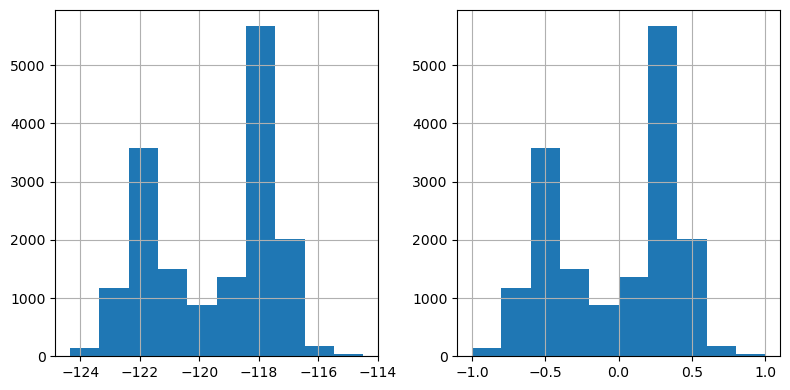

In [23]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)


plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
housing_num["longitude"].hist()


housing_scaled_df = pd.DataFrame(
    housing_num_min_max_scaled,
    columns=housing_num.columns
)

plt.subplot(1, 2, 2)
housing_scaled_df["longitude"].hist()

plt.tight_layout()
plt.show()

Standardization (mean = 0, std = 1)

<Axes: >

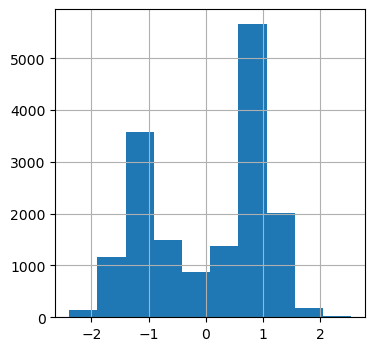

In [24]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

housing_scaled_df = pd.DataFrame(
    housing_num_std_scaled,
    columns=housing_num.columns
)

housing_scaled_df["longitude"].hist(figsize=(4, 4))

Non-linear relationships can be captured by linear models by transforming features with the RBF (Radial Basis Function).

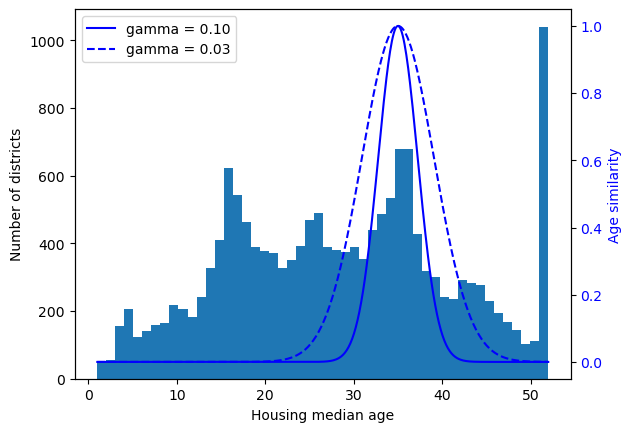

In [25]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

ages = np.linspace(housing["housing_median_age"].min(),
                   housing["housing_median_age"].max(),
                   500).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()  # create a twin axis that shares the same x-axis
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")
plt.show()

inverse_transform

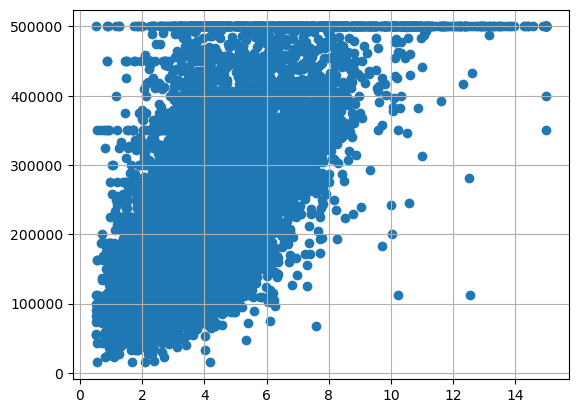

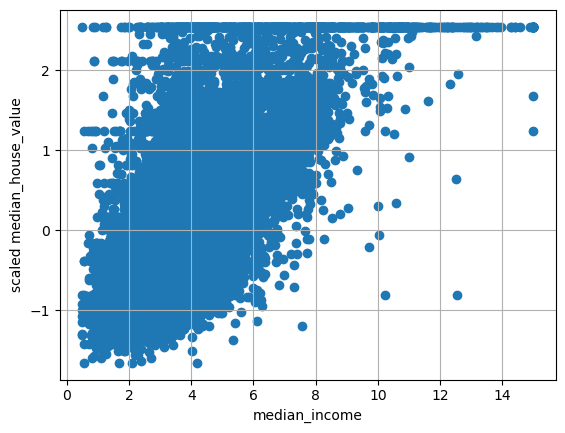

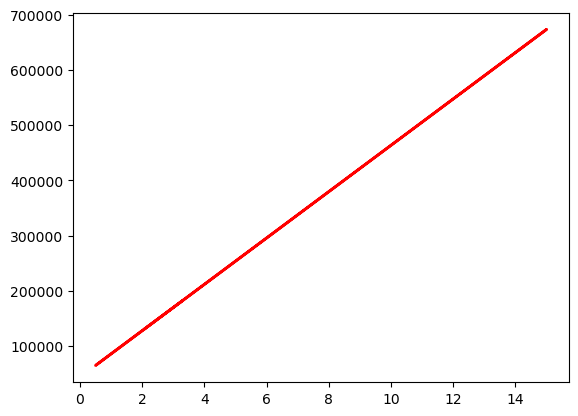

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

plt.scatter(housing["median_income"], housing_labels)
plt.grid(True)
plt.show()

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

plt.scatter(housing["median_income"], scaled_labels)
plt.xlabel("median_income")
plt.ylabel("scaled median_house_value")
plt.grid(True)
plt.show()

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)

some_new_data = housing[["median_income"]]

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

plt.plot(some_new_data.values.ravel(),
         predictions.ravel(),
         color='red', linewidth=2, label="Predictions")

plt.show()


Simpler option

In [27]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(),
                                   transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)

Log trasformer

array([[<Axes: title={'center': 'population'}>]], dtype=object)

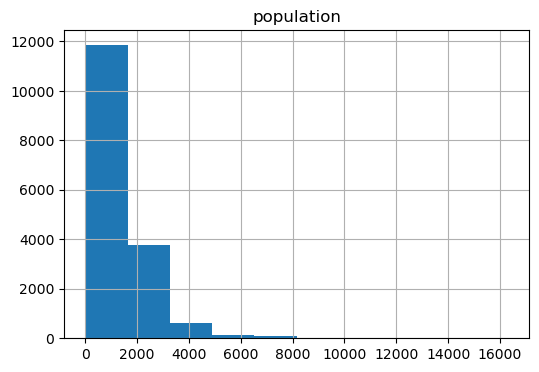

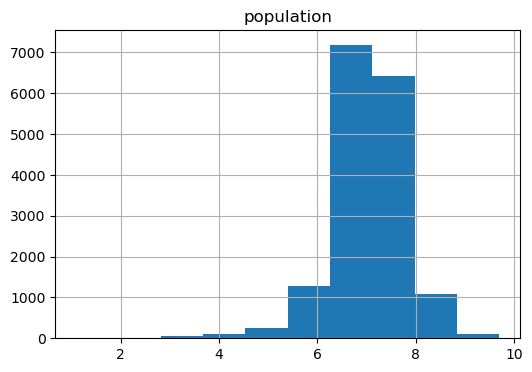

In [28]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

housing[["population"]].hist(figsize=(6,4))
log_pop.hist(figsize=(6,4))

RBF similarity

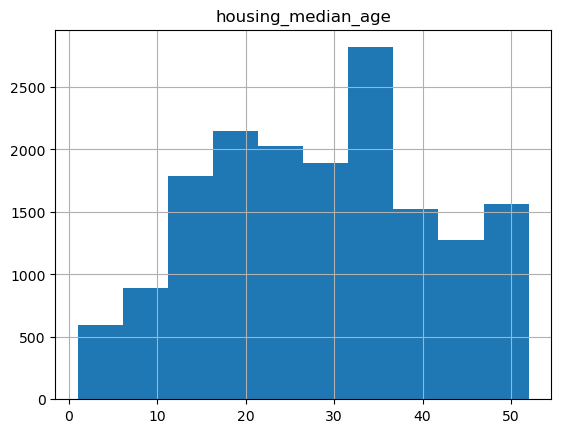

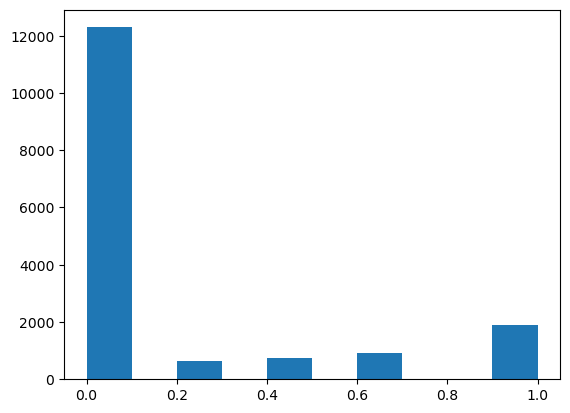

In [29]:
rbf_transformer = FunctionTransformer(rbf_kernel,
                                      kw_args=dict(Y=[[35.]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])

housing[["housing_median_age"]].hist()
plt.show()

plt.hist(age_simil_35)
plt.show()


# equivalent to:
# age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

Custom clusterSimilarity

In [30]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10,
                              random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

In [31]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]])

similarities[:3].round(2)

array([[0.  , 0.97, 0.  , 0.  , 0.  , 0.08, 0.  , 0.  , 0.13, 0.57],
       [0.12, 0.  , 0.98, 0.03, 0.  , 0.  , 0.  , 0.54, 0.  , 0.  ],
       [0.  , 0.75, 0.  , 0.  , 0.  , 0.44, 0.  , 0.  , 0.27, 0.28]])

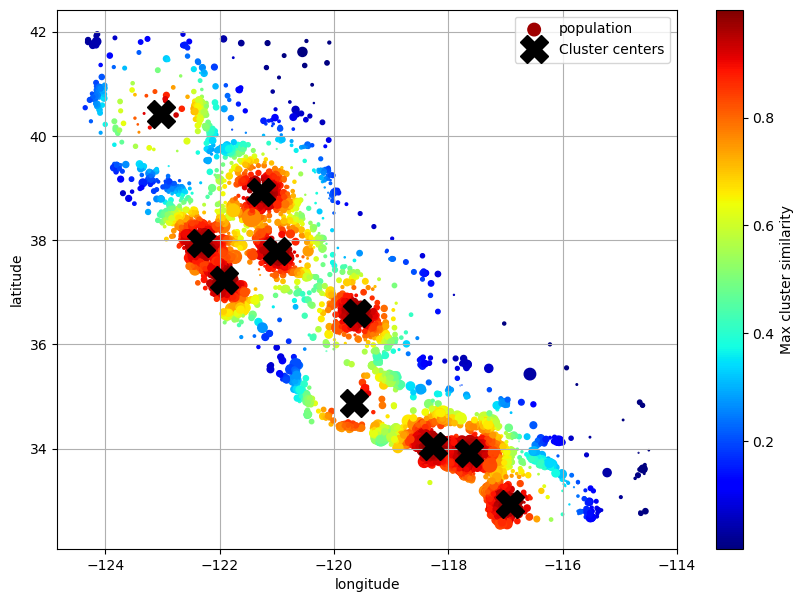

In [32]:
housing["Max cluster similarity"] = similarities.max(axis=1)

housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="Max cluster similarity",
             cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))

plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")

plt.legend(loc="upper right")
plt.show()

# Remove temporary feature used only for visualization
housing.drop("Max cluster similarity", axis=1, inplace=True) 

# Transformation Pipelines
Execute the transformation steps in the correct order

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

# or
num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

In [34]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

for num and categorical colums:

In [35]:
from sklearn.compose import make_column_selector, make_column_transformer

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore"))

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

housing_prepared = preprocessing.fit_transform(housing)

pipeline code:

In [36]:
from sklearn.compose import ColumnTransformer

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())

preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)  # one column remaining: housing_median_age


housing_prepared = preprocessing.fit_transform(housing)
print(housing_prepared.shape)
preprocessing.get_feature_names_out()

(16512, 24)


array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

In [37]:
# to dataframe for visualization
housing_prepared_df = pd.DataFrame(
    housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=housing.index
)

housing_prepared_df.head(2)

,bedrooms__ratio,rooms_per_house__ratio,people_per_house__ratio,log__total_bedrooms,log__total_rooms,log__population,log__households,log__median_income,geo__Cluster 0 similarity,geo__Cluster 1 similarity,...,geo__Cluster 6 similarity,geo__Cluster 7 similarity,geo__Cluster 8 similarity,geo__Cluster 9 similarity,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__housing_median_age
13096,1.846624,-0.866027,-0.330204,1.324114,0.637892,0.456906,1.310369,-1.071522,8.708837e-08,9.712456e-01,...,7.114441e-04,3.070969e-17,1.314047e-01,5.740031e-01,0.0,0.0,0.0,1.0,0.0,1.861119
14973,-0.508121,0.024550,-0.253616,-0.252671,-0.063576,-0.711654,-0.142030,1.194712,1.181328e-01,9.738096e-14,...,3.045359e-27,5.437838e-01,1.735342e-09,2.275194e-10,1.0,0.0,0.0,0.0,0.0,0.907630


# Select and train a model

linear regression (housing -> housing_labels through preprocessing pipeline)

In [38]:
lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


comparing results

In [39]:
housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2) # -2 = rounded to the nearest hundred

array([242800., 375900., 127500.,  99400., 324600.])

In [40]:
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

performance mesure RMSE

In [41]:
from sklearn.metrics import root_mean_squared_error
lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

68647.95686706662

underfitting so i will try a more powerful model

In [42]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

housing_predictions = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
tree_rmse

0.0

rmse error = 0.0? probably overfitting

cross-validation <br>
(split the training set into 10 folds, train on 9 folds and evaluate on the remaining one. Repeat this process 10 times, then return an array of validation scores.)

In [43]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

pd.Series(tree_rmses).describe()

count       10.000000
mean     66366.983603
std       1976.844743
min      63557.655007
25%      65004.623899
50%      65886.897085
75%      68129.026040
max      69530.301101
dtype: float64

try random forset model

In [44]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))

forest_rmses = -cross_val_score(forest_reg, housing, housing_labels,
                                scoring="neg_root_mean_squared_error", cv=10,
                                n_jobs=-1)

pd.Series(forest_rmses).describe()

count       10.000000
mean     46938.209246
std       1018.397196
min      45522.649195
25%      46291.334639
50%      47021.703303
75%      47321.521991
max      49140.832210
dtype: float64

# Fine-tune your model

grid search

In [45]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])

param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
     'random_forest__max_features': [4, 6, 8]},
    {'preprocessing__geo__n_clusters': [10, 15],
     'random_forest__max_features': [6, 8, 10]},
]

grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error',
                           n_jobs=-1)

grid_search.fit(housing, housing_labels)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'preprocessing__geo__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, ...]}]"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"


best hyperparameter combination found:

In [46]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

score of each hyperparameter combination tested during the grid search:

In [47]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
12,15,6,43007,43683,44158,43616
13,15,8,43697,44011,44819,44176
7,10,6,43710,44133,45227,44356
9,10,6,43710,44133,45227,44356
6,10,4,43798,44233,45100,44377


randomized search (generally better than grid search)

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50),
                  'random_forest__max_features': randint(low=2, high=20)}

rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42,
    n_jobs=-1)

rnd_search.fit(housing, housing_labels)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'preprocessing__geo__n_clusters': <scipy.stats....001365AE27EC0>, 'random_forest__max_features': <scipy.stats....001365A32E390>}"
,n_iter,10
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [49]:
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)
cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
1,45,9,41178,42385,42712,42092
8,32,7,41374,42579,43182,42378
0,41,16,42397,42640,43175,42738
5,42,4,41761,43348,43690,42933
2,23,8,42421,43138,43585,43048


Analyze the best models and their errors

In [50]:
final_model = rnd_search.best_estimator_
feature_importances = final_model["random_forest"].feature_importances_

sorted(zip(feature_importances.round(4),
           final_model["preprocessing"].get_feature_names_out()),
           reverse=True)

[(0.1875, 'log__median_income'),
 (0.0751, 'cat__ocean_proximity_INLAND'),
 (0.0648, 'bedrooms__ratio'),
 (0.0518, 'rooms_per_house__ratio'),
 (0.0483, 'people_per_house__ratio'),
 (0.0421, 'geo__Cluster 3 similarity'),
 (0.0231, 'geo__Cluster 18 similarity'),
 (0.0229, 'geo__Cluster 17 similarity'),
 (0.0218, 'geo__Cluster 22 similarity'),
 (0.0196, 'geo__Cluster 40 similarity'),
 (0.0181, 'geo__Cluster 41 similarity'),
 (0.018, 'geo__Cluster 35 similarity'),
 (0.0167, 'geo__Cluster 10 similarity'),
 (0.016, 'geo__Cluster 2 similarity'),
 (0.0157, 'geo__Cluster 6 similarity'),
 (0.0151, 'geo__Cluster 32 similarity'),
 (0.0145, 'geo__Cluster 43 similarity'),
 (0.0132, 'geo__Cluster 21 similarity'),
 (0.0126, 'geo__Cluster 7 similarity'),
 (0.0125, 'geo__Cluster 39 similarity'),
 (0.0125, 'geo__Cluster 26 similarity'),
 (0.0124, 'geo__Cluster 31 similarity'),
 (0.0123, 'geo__Cluster 38 similarity'),
 (0.0115, 'geo__Cluster 34 similarity'),
 (0.0112, 'geo__Cluster 14 similarity'),
 (0.01

# Evaluate Your System on the Test Set

In [51]:
x_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(x_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

41592.03010634003


Calculate the confidence interval

In practice, it generates k lists from the list of errors by randomly sampling values (with replacement), computes k mean errors, then trims the lowest 2.5% and highest 2.5% of the k means, and returns the lowest and highest values.

In [52]:
from scipy import stats

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = stats.bootstrap([squared_errors], rmse,
                              confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval

print(rmse_lower, rmse_upper)

39664.07350648277 43834.65613955853


# Launch, monitor and maintain your system

save the model

In [53]:
import joblib

joblib.dump(final_model, "../models/my_california_housing_model.pkl")

['../models/my_california_housing_model.pkl']

deploy

In [54]:
import joblib

final_model_reloaded = joblib.load("../models/my_california_housing_model.pkl")

new_data = housing.iloc[:5]  # pretend these are new districts
predictions = final_model_reloaded.predict(new_data)

print(predictions)

[440395.12 452443.09 105447.   100697.   339535.03]
